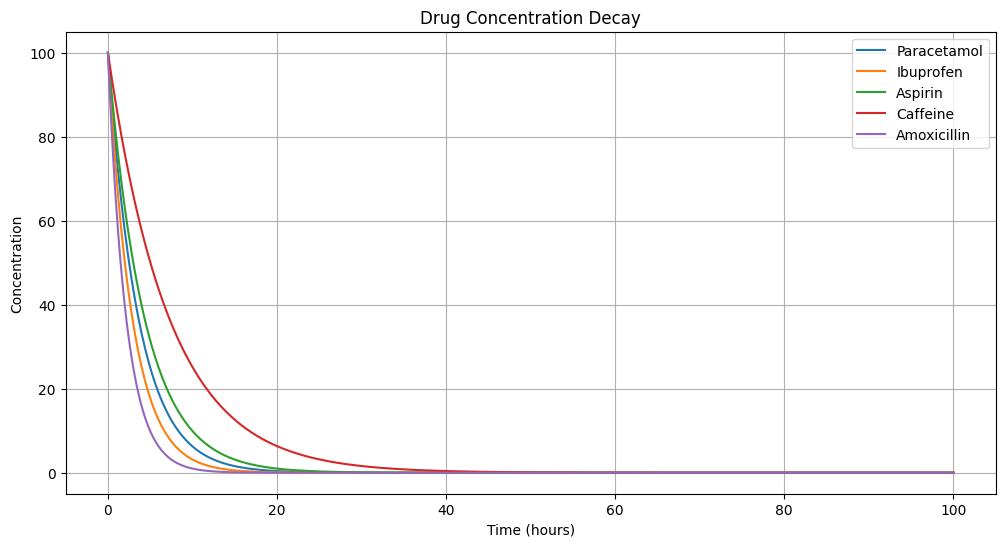

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv("drugs_dataset.csv")

# Time axis (0 to 100 hours)
t = np.linspace(0, 100, 500)

# Dose
D = 100  # mg

plt.figure(figsize=(12,6))

# Plot for first 5 drugs
for i in range(5):
    k = df.loc[i, "k"]
    drug = df.loc[i, "Drug"]

    C = D * np.exp(-k * t)
    plt.plot(t, C, label=drug)

plt.xlabel("Time (hours)")
plt.ylabel("Concentration")
plt.title("Drug Concentration Decay")
plt.legend()
plt.grid()
plt.show()

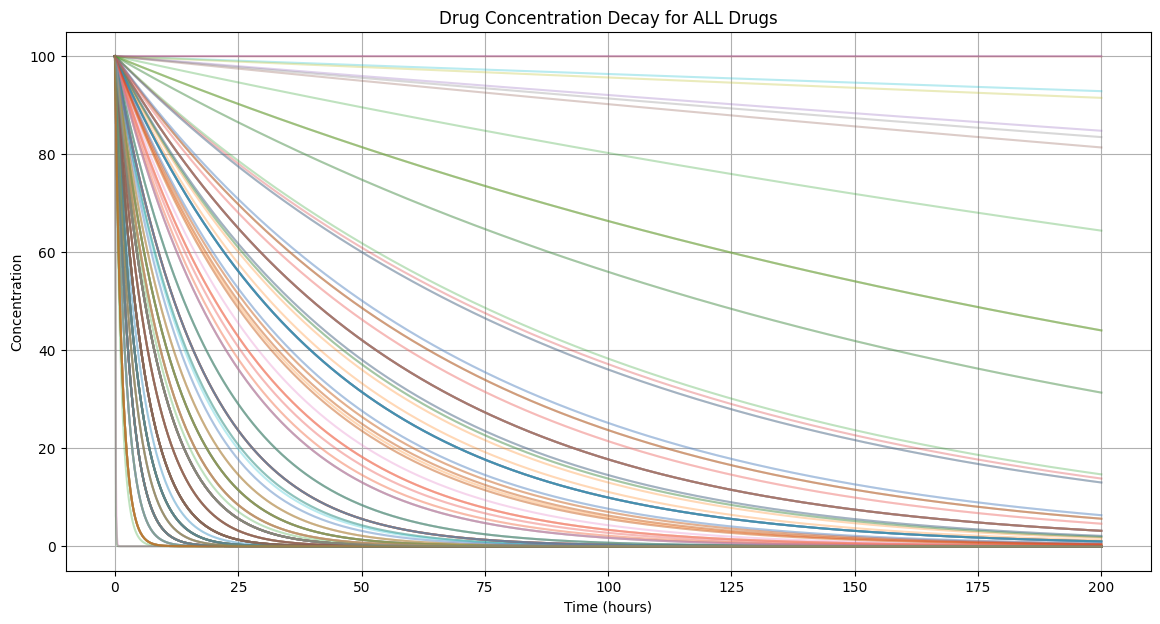

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv("drugs_dataset.csv")

# Time axis (hours)
t = np.linspace(0, 200, 1000)

# Dose (same for all)
D = 100  

plt.figure(figsize=(14,7))

# Plot all drugs
for i in range(len(df)):
    k = df.loc[i, "k"]
    drug = df.loc[i, "Drug"]

    C = D * np.exp(-k * t)

    plt.plot(t, C, alpha=0.3)  # transparency to avoid clutter

plt.xlabel("Time (hours)")
plt.ylabel("Concentration")
plt.title("Drug Concentration Decay for ALL Drugs")
plt.grid()

plt.show()
"""Generic Name	Brand Name Examples	Half-life (T1/2*)
Alprazolam	Xanax	6-12 hours
Amiodarone	Pacerone	15-142 days
Amphetamine	Adderall, Dexedrine	10-12 hours
Atenolol	Tenormin	6-7 hours
Clonazepam	Klonopin	18-50 hours
Cocaine	-	50 minutes
Diazepam	Valium	20-100 hours
Donepezil	Aricept	70 hours
Dutasteride	Avodart	5 weeks
Erenumab	Aimovig	28 days
Fluoxetine	Prozac	2-4 days
Heroin	-	2-6 minutes
Lead	-	28-36 days
Mercury	-	65 days
Methamphetamine	Desoxyn	6.4-15 hours
Methylphenidate	Concerta, Ritalin	2-3 hours
Plutonium	-	40 years (liver), 100 years (bone)
Phenytoin	Dilantin, Phenytek	7-42 hours
Tetrahydrocannabinol (cannabis/marijuana)	-	Infrequent users: 1.3 days
Regular users: 13 days
Warfarin	Coumadin, Jantoven	1 week-"""

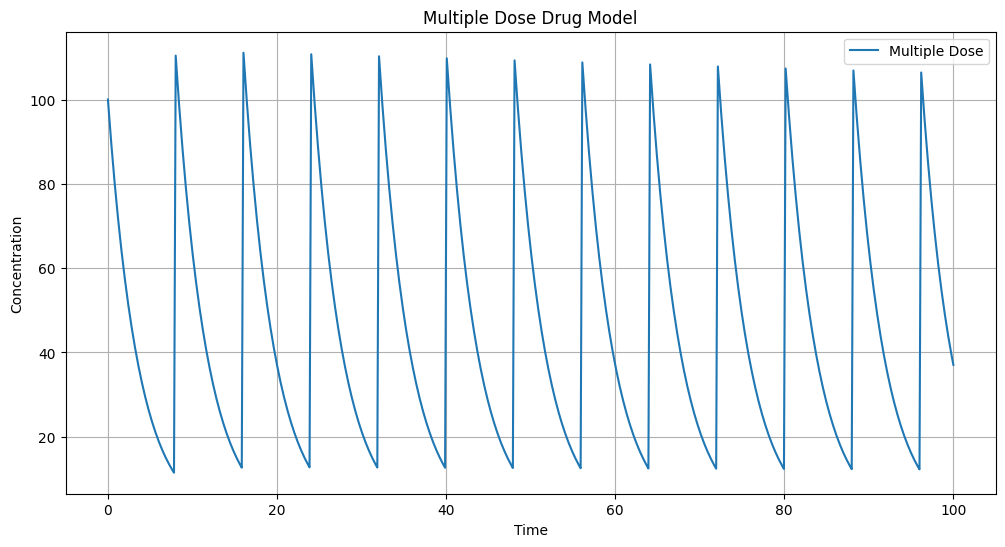

In [4]:
#MULTIPLE DOSE SIMULATION
def multiple_dose(k, dose, interval, t):
    C = np.zeros_like(t)

    for i in range(len(t)):
        for d in range(int(t[i] // interval) + 1):
            C[i] += dose * np.exp(-k * (t[i] - d * interval))
    
    return C

plt.figure(figsize=(12,6))

k = df.loc[0, "k"]  # first drug
C_multi = multiple_dose(k, 100, 8, t)

plt.plot(t, C_multi, label="Multiple Dose")
plt.xlabel("Time")
plt.ylabel("Concentration")
plt.title("Multiple Dose Drug Model")
plt.legend()
plt.grid()
plt.show()

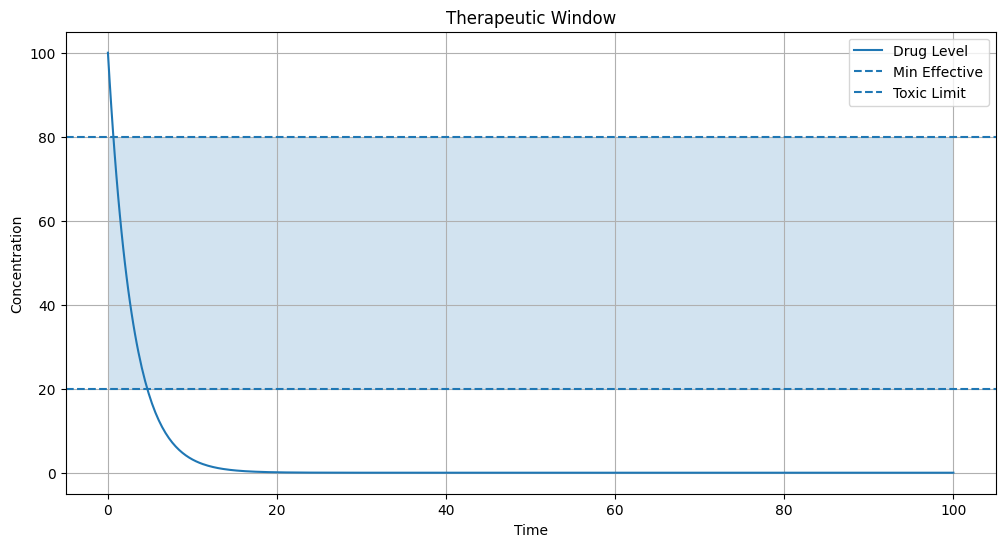

In [6]:
#SAFE vs TOXIC RANGE
therapeutic_min = 20
therapeutic_max = 80

plt.figure(figsize=(12,6))

k = df.loc[1, "k"]
C = 100 * np.exp(-k * t)

plt.plot(t, C, label="Drug Level")
plt.axhline(therapeutic_min, linestyle='--', label="Min Effective")
plt.axhline(therapeutic_max, linestyle='--', label="Toxic Limit")

plt.fill_between(t, therapeutic_min, therapeutic_max, alpha=0.2)

plt.xlabel("Time")
plt.ylabel("Concentration")
plt.title("Therapeutic Window")
plt.legend()
plt.grid()
plt.show()